# Challenge Part 2: Circuit QED

## 2.2

In [1]:
import dynamiqs as dq
import matplotlib.pyplot as plt
import jax.numpy as jnp
import scipy.constants as const

In [28]:
na, nb = 20, 5

# All frequency units are Gigahertz
omega_a = 5.26
omega_b = 7.70
phi_a = 0.06
phi_b = 0.29
Ej = 42.76
delta_Ej = 0.47
omega_d = 7.623
omega_p = 2.891
eps_d = -3.815e-3
eps_p = 0.122

In [29]:
a, b = dq.destroy(na, nb)

H0 = omega_a * a.dag() @ a + omega_b * b.dag() @ b

phi_hat = phi_a * (a + a.dag()) + phi_b * (b + b.dag())
eps_sin = lambda t: jnp.sin(eps_p * jnp.cos(omega_p * t))
eps_cos = lambda t: jnp.cos(eps_p * jnp.cos(omega_p * t))
H_ats = dq.modulated(eps_sin, -2 * Ej * phi_hat.sinm()) + \
        dq.modulated(eps_cos, 2 * delta_Ej * phi_hat.cosm())

f = lambda t: jnp.cos(omega_d * t)
H_d = dq.modulated(f, 2 * eps_d * (b + b.dag()))

H = H0 + H_ats + H_d

/home/jovyan/.qbraid/environments/alice_g9lq38/pyenv/lib/python3.11/site-packages/equinox/_module.py:1096: UserWarning: A `SparseDIAQArray` has been converted to a `DenseQArray` while computing its matrix exponential.
  return self.__func__(self.__self__, *args, **kwargs)


In [38]:
psi0 = dq.fock((na, nb), (0, 0))

kappa_a = 9.3e-6
kappa_b = 2.6e-3
loss_ops = [jnp.sqrt(kappa_a) * a, jnp.sqrt(kappa_b) * b]

T = 100
t_save = jnp.linspace(0, T, 200)
res = dq.mesolve(H, loss_ops, psi0, t_save)

|██████████| 100.0% ◆ elapsed 6.44s ◆ remaining 0.00ms  


100%|██████████| 50/50 [00:04<00:00, 11.24it/s]


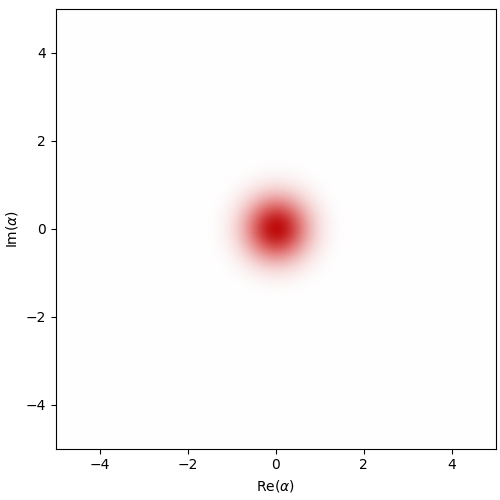

In [39]:
rho_a = dq.ptrace(res.states, 0)
dq.plot.wigner_gif(rho_a)